## Image Transformation

In [44]:
import numpy as np
import pandas as pd 
import os
import matplotlib.pyplot as plt
from PIL import Image

from image_processing_tools import construct_feature, data_loading

#### Approach

+ Data Loading: Images, Labels
+ Data Transformation
+ Data Preprocessing 
+ Data Storage 

## Data Loading

In [2]:
# define constants --> loading content for data transformation
text_file = "mobile_labels.txt"
image_path = "D:\\Machine_Learning\\Portfolio_Project_Machine_Learning\\Mobile_Phone_Recognition\\mobile_phone_images\\mobile_images"

# load images and labels 
mobile_images = os.listdir(image_path)
mobile_labels = data_loading(directory=text_file, content_type="Mobile Labels")

In [6]:
print(f"Mobile Labels (Size): {mobile_labels.shape[0]}")
print(f"{mobile_labels[:5]} \n")
print(f"Mobile Images (Size): {len(mobile_images)}")
print(f"{mobile_images[:5]}")

Mobile Labels (Size): 800
['Samsung SM-A156B Galaxy A15 Dual SIM 5G 4GB RAM 128GB Blue Black EU\n'
 'Samsung SM-A556B Galaxy A55 5G Dual SIM 8GB 128GB Awesome Lemon EU\n'
 'Motorola Moto G54 256GB Blue 5G Android Smartphone 6.5 Inches 12GB RAM 16MP\n'
 'Xiaomi 14 Ultra 5G 16GB/512GB White (White) Dual SIM\n'
 'Samsung Galaxy S20 FE 5G 6GB/128GB Purple (Lavender) Dual SIM G781B\n'] 

Mobile Images (Size): 800
['image_001.jpg', 'image_002.jpg', 'image_003.jpg', 'image_004.jpg', 'image_005.jpg']


## Data Transformation

Approach:
+ convert labels and images into frames
+ extract content from labels (check requirement.txt)
+ create feature with brand names seperately

In [9]:
# convert labels and image list into frames
frame1 = construct_feature("Labels", mobile_labels)
frame2 = construct_feature("Image_file", mobile_images)

# concatenate both frames
mobile_df = pd.concat([frame1, frame2], axis=1)

In [10]:
mobile_df.head()

,Labels,Image_file
0,Samsung SM-A156B Galaxy A15 Dual SIM 5G 4GB RA...,image_001.jpg
1,Samsung SM-A556B Galaxy A55 5G Dual SIM 8GB 12...,image_002.jpg
2,Motorola Moto G54 256GB Blue 5G Android Smartp...,image_003.jpg
3,Xiaomi 14 Ultra 5G 16GB/512GB White (White) Du...,image_004.jpg
4,Samsung Galaxy S20 FE 5G 6GB/128GB Purple (Lav...,image_005.jpg


In [ ]:
mobile_df["Labels"].unique()


array(['Samsung SM-A156B Galaxy A15 Dual SIM 5G 4GB RAM 128GB Blue Black EU\n',
       'Samsung SM-A556B Galaxy A55 5G Dual SIM 8GB 128GB Awesome Lemon EU\n',
       'Motorola Moto G54 256GB Blue 5G Android Smartphone 6.5 Inches 12GB RAM 16MP\n',
       'Xiaomi 14 Ultra 5G 16GB/512GB White (White) Dual SIM\n',
       'Samsung Galaxy S20 FE 5G 6GB/128GB Purple (Lavender) Dual SIM G781B\n',
       'Samsung Galaxy S22+ 5G 8GB/128GB Black (Phantom Black) Dual SIM SM-S906\n',
       'Samsung Galaxy A55 Smartphone 128GB 5G Midnight Blue\n',
       'Samsung Smartphone Galaxy S20, 5G, 12GB + 128GB, Grey\n',
       'Samsung Galaxy A03 Smartphone 64GB, 4GB RAM, Dual SIM, Blue\n',
       'SAMSUNG S20 ULTRA 128GB Phone - Cosmic gray\n',
       'SAMSUNG - Smartphone Galaxy A14 5G Silver 6.6 IN 4GB 64GB Android 13\n',
       'Samsung Galaxy Note Pack 20 5G - 6.7" Display (AMOLED FHD+, 8GB RAM + 256GB Storage, Quad Rear Camera, 4300mAh Fast Charge 25W) Mystic Green [ES Version]\n',
       'Smartphone

## Data Preprocessing

After constructing a dataframe with labels and images, we focus on extracting the name of the mobile brand from the label and combine them in multiple frames. The target = "brand name"

In [ ]:
# extract label data
labels = mobile_df["Labels"].apply(lambda text: text.capitalize())

# extract brands from the label data 
mobile_df["Company"] = mobile_df["Labels"].str.split(" ", expand=True).loc[:, 0]


In [33]:
# extract the model from the label data 
phone_model = mobile_df["Labels"].str.split(" ", expand=True).loc[:,1:2]
mobile_df["Model"] = phone_model[[1,2]].agg(lambda x: " ".join(x), axis=1)

In [39]:
# reorganise the columns
reorganised_columns = ["Image_file", "Labels", "Model", "Company"]
mobile_df = mobile_df[reorganised_columns]
mobile_df.head()

,Image_file,Labels,Model,Company
0,image_001.jpg,Samsung SM-A156B Galaxy A15 Dual SIM 5G 4GB RA...,SM-A156B Galaxy,Samsung
1,image_002.jpg,Samsung SM-A556B Galaxy A55 5G Dual SIM 8GB 12...,SM-A556B Galaxy,Samsung
2,image_003.jpg,Motorola Moto G54 256GB Blue 5G Android Smartp...,Moto G54,Motorola
3,image_004.jpg,Xiaomi 14 Ultra 5G 16GB/512GB White (White) Du...,14 Ultra,Xiaomi
4,image_005.jpg,Samsung Galaxy S20 FE 5G 6GB/128GB Purple (Lav...,Galaxy S20,Samsung


In [40]:
mobile_df.isnull().sum()

Image_file    0
Labels        0
Model         0
Company       0
dtype: int64

In [41]:
mobile_df.iloc[27]

Image_file                                        image_028.jpg
Labels        Samsung Galaxy A52 5G Smartphone 128GB, 6GB RA...
Model                                                Galaxy A52
Company                                                 Samsung
Name: 27, dtype: object

In [42]:
image_file28 = os.path.join(image_path, "image_028.jpg")
image_file28

'D:\\Machine_Learning\\Portfolio_Project_Machine_Learning\\Mobile_Phone_Recognition\\mobile_phone_images\\mobile_images\\image_028.jpg'

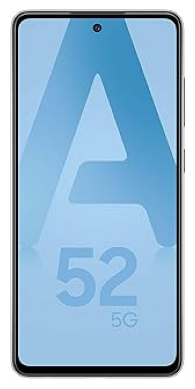

In [46]:
# Load the image
img = Image.open(image_file28)

# Plot the image
plt.imshow(img)
plt.axis('off')  # Turn off axis labels
plt.show()


## Data Storage 

In [48]:
# save this dataset as csv file
filename = "image_dataset.csv"
mobile_df.to_csv(filename)